In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


# 1. Load and Train a Model

salary = pd.read_csv('salary.csv', index_col=0)

X = salary[['YearsExperience']]
y = salary['Salary']

model = LinearRegression()
model.fit(X, y)

salary['predicted_salary'] = model.predict(X)

In [3]:
# 2. Compute Residuals

salary['residual'] = y - salary['predicted_salary']

salary.head(5)

# When the residual is positive it underpredicted, when it's negative it overpredicted

,YearsExperience,Salary,predicted_salary,residual
0,1.2,39344.0,36188.158752,3155.841248
1,1.4,46206.0,38078.151217,8127.848783
2,1.6,37732.0,39968.143681,-2236.143681
3,2.1,43526.0,44693.124842,-1167.124842
4,2.3,39892.0,46583.117306,-6691.117306


In [4]:
# 3. Compute MAE by Hand

salary['abs_residual'] = abs(salary['residual'])

mae = round(salary['abs_residual'].mean(), 2)

print(f"On average, the salary predictions are off by ${mae}")

On average, the salary predictions are off by $4644.2


In [5]:
# 4. Verify with Sklearn

mae_auto = mean_absolute_error(y, salary['predicted_salary'])
rmse = np.sqrt(mean_squared_error(y, salary['predicted_salary']))

print(f"MAE: {mae_auto:.2f} | RMSE: {rmse:.2f}")

# RMSE is larger, there's probably larger values pulling the mean up

MAE: 4644.20 | RMSE: 5592.04


In [6]:
# 5. Compute R-Squared

r2 = r2_score(y, salary['predicted_salary'])

print(f"R2: {r2:.4f}")

# R2 of 1 means the model is a good fit, 0 means it doesn't fit at all
# Our model's predictions are pretty close to the actual

R2: 0.9570


# 6 Write a Manager Summary

- Predictions are off on average by $4644.
- Some errors are large because the RMSE is larger than the MAE.
- The model is better than guessing because the R2 is .95
- No because we are still over $4000 off.

In [7]:
#7 Compare to a Second Model
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X, y)
y_pred_tree = tree.predict(X)
mae_t = mean_absolute_error(y, y_pred_tree)
rmse_t = np.sqrt(mean_squared_error(y, y_pred_tree))
r2_t = r2_score(y, y_pred_tree)

print(f"{'Metric':<8} {'Linear Reg':>12} {'Decision Tree':>15}")
print("-" * 38)
print(f"{'MAE':<8} {mae:>12,.2f} {mae_t:>15,.2f}")
print(f"{'RMSE':<8} {rmse:>12,.2f} {rmse_t:>15,.2f}")
print(f"{'R2':<8} {r2:>12.4f} {r2_t:>15.4f}")

#The DecisionTreeRegressor performs better. No because it might be overfitted to the data.

Metric     Linear Reg   Decision Tree
--------------------------------------
MAE          4,644.20          372.10
RMSE         5,592.04        1,299.70
R2             0.9570          0.9977


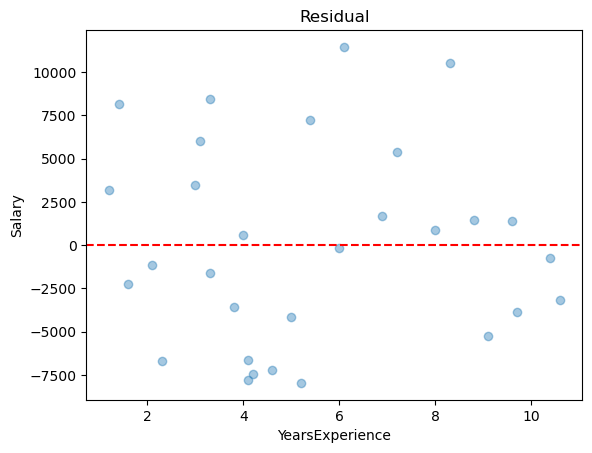

In [14]:
#8 Visualize the Residuals

plt.scatter(X, salary["residual"], alpha= .4)
plt.title("Residual")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.axhline(0, linestyle= "--", color="Red")

- The errors have a good spread and is uniform.
- It does not have a pattern which means its a good fit. If there was a pattern then it's not a good fit.

In [18]:
def evaluate_regression(X, y):
    model = LinearRegression()
    model.fit(X,y)
    predicted = model.predict(X)
    residual = (y - predicted).abs()
    MAE = mean_absolute_error(y, predicted)
    RMSE = np.sqrt(mean_squared_error(y, predicted))
    R2 = r2_score(y, predicted)

    print(f"{'Metric':<8} {'Linear Reg':>12}")
    print("-" * 38)
    print(f"{'MAE':<8} {MAE:>12,.2f}")
    print(f"{'RMSE':<8} {RMSE:>12,.2f}")
    print(f"{'R2':<8} {R2:>12.4f}")
    print("Largest residual", round(residual.max(),2))

evaluate_regression(X, y)

Metric     Linear Reg
--------------------------------------
MAE          4,644.20
RMSE         5,592.04
R2             0.9570
Largest residual 11448.03


In [21]:
insurance_df = pd.read_csv("Insurance.csv")

X = insurance_df[["age"]]
y = insurance_df["charges"]

evaluate_regression(X, y)

Metric     Linear Reg
--------------------------------------
MAE          9,055.15
RMSE        11,551.67
R2             0.0894
Largest residual 47829.47
